## setup

libraries:

In [2]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os

graphs' datasets:

In [3]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot"
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" #
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" #
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

functions:

In [ ]:

def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}

    #list of edges run for each node of the graph

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph

    return adjacency_list

def extract_edges(graph):
    edges = []
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            edge = (node, neighbor)
            if edge not in edges and (neighbor, node) not in edges:
                edges.append(edge)
    return edges

def bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree

def dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}

    visited.add(root)

    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            dfs_tree(graph, neighbor, visited, tree)

    print(tree)

    return tree


def missing_edges(spanning_tree, full_edge_list):
    # edges of the spanning tree
    sp_edges = [(node, child) for node, children in spanning_tree.items() for child in children]
    sp_edges_set = set(sp_edges)
    # all edges of the graph
    full_edges_set = set(full_edge_list)
    # edges not present in the spanning tree
    non_tree_edges = full_edges_set - sp_edges_set
    return non_tree_edges

def compute_postorder_spacing(tree, node, spacing, boundaries, min_separation=1.0):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree or not tree[node]:  # No children
        boundaries[node] = (spacing[node], spacing[node])
        return
    
    children = tree[node]
    
    # Process all children first
    for child in children:
        compute_postorder_spacing(tree, child, spacing, boundaries, min_separation)
    
    # Special handling for nodes with 3+ children
    if len(children) >= 3:
        # Ensure adequate spacing between all children
        for i in range(len(children) - 1):
            current_child = children[i]
            next_child = children[i + 1]
            
            # Get current right boundary and next left boundary
            _, current_right = boundaries[current_child]
            next_left, _ = boundaries[next_child]
            
            # If children are too close, shift the next child and all its subtree
            if next_left - current_right < min_separation:
                shift_amount = (current_right + min_separation) - next_left
                
                # Shift the next child and all nodes in its subtree
                shift_subtree(tree, next_child, shift_amount, spacing, boundaries)
    
    # Calculate leftmost and rightmost boundaries from children
    leftmost = min(boundaries[child][0] for child in children)
    rightmost = max(boundaries[child][1] for child in children)
    
    # Center the parent node with respect to its children
    midpoint = (leftmost + rightmost) / 2
    spacing[node] = midpoint
    
    # Set the parent's boundaries to encompass all children
    # Add some padding to ensure parent doesn't overlap with other nodes
    padding = 0.5  # Adjust as needed
    boundaries[node] = (leftmost - padding, rightmost + padding)

def shift_subtree(tree, node, shift_amount, spacing, boundaries):
    """ Shift a node and all its descendants by a specified amount. """
    # Shift current node
    spacing[node] += shift_amount
    left, right = boundaries[node]
    boundaries[node] = (left + shift_amount, right + shift_amount)
    
    # Recursively shift all descendants
    if node in tree:
        for child in tree[node]:
            shift_subtree(tree, child, shift_amount, spacing, boundaries)

def not_using_compute_postorder_spacing(tree, node, spacing, boundaries):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree:
        return

    leftmost, rightmost = None, None

    for child in tree[node]:
        compute_postorder_spacing(tree, child, spacing, boundaries)
        
        # Set boundaries for subtree
        if leftmost is None:
            leftmost = boundaries[child][0]
        rightmost = boundaries[child][1]

    if leftmost is not None:
        # Assign horizontal spacing based on children's boundaries
        boundaries[node] = (leftmost, rightmost)
        spacing[node] = (leftmost + rightmost) / 2
    else:
        # Leaf node case
        boundaries[node] = (spacing[node], spacing[node])

def assign_preorder_positions(tree, node, x_positions, y_positions, depth, spacing):
    """ Preorder traversal to assign final x and y coordinates. """
    x_positions[node] = spacing[node]
    y_positions[node] = -depth  # Negative depth for layered layout

    for child in tree[node]:
        assign_preorder_positions(tree, child, x_positions, y_positions, depth + 1, spacing)

def draw_layered_tree(tree, title="Level-Based Tree Layout", show_node_ids=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    if show_node_ids:
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, node, ha='center', va='center', fontsize=5,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    else: # without node ids
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, " ", ha='center', va='center', fontsize=2,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    # Draw red dotted lines at each level
    unique_levels = sorted(set(y_positions.values()), reverse=True)
    for i, level in enumerate(unique_levels):
        plt.axhline(y=level, color='red', linestyle='--', linewidth=0.5)
        plt.text(min(x_positions.values()) - 15.5, level + 0.1, f"level {i}", color='red', fontsize=6, va='center')

    plt.title(title)
    plt.axis('off')
    plt.show()

def draw_tree_with_all_edges(non_tree_edges, tree, title="Level-Based Tree Layout", random=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=2,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    if random:
        # draw the non-tree edges as bended lines between nodes with different colors:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(non_tree_edges)))
        for edge, color in zip(non_tree_edges, colors):
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]

            # Generate random curvature
            curvature = np.random.uniform(-0.2, 0.2)

            # Calculate control points for Bezier curve
            ctrl_x = (x1 + x2) / 2 + curvature * (y2 - y1)
            ctrl_y = (y1 + y2) / 2 + curvature * (x1 - x2)

            # Plot Bezier curve
            bezier_x = [x1, ctrl_x, x2]
            bezier_y = [y1, ctrl_y, y2]
            plt.plot(bezier_x, bezier_y, linestyle='--', linewidth=0.2, color=color)
    else:
        for edge in non_tree_edges:
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]
            plt.plot([x1, x2], [y1, y2], 'b--', linewidth=0.2)

    plt.title(title)
    plt.axis('off')
    plt.show()

def save_drawing(tree, image_title):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=8,
                bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    plt.title(image_title)
    plt.axis('off')
    #plt.savefig(image_title)


## general usage:

Displaying bfs and dfs trees for "LesMiserables" garph:

In [5]:
# choosing the graph and the root node
file_name = data_name_1
graph = parse_dot_file(file_name)
root_node = "1"

#running bfs and dfs on the graph
bfs_result = bfs_tree(graph, root_node)
dfs_result = dfs_tree(graph, root_node)
print("BFS Tree: ", bfs_result)

# plotting the trees with level-based layout with the nodes ids
display_node_id = False # by default, it displays the node ids with display_node_id = True
#draw_layered_tree(bfs_result, "BFS Layered Tree on LesMiserables with root node 1", display_node_id)
#draw_layered_tree(dfs_result, "DFS Layered Tree on LesMiserables with root node 1", display_node_id) 

{'1': ['10'], '10': ['3'], '3': ['13'], '13': ['11'], '11': ['2'], '2': ['12'], '12': ['4'], '4': ['14'], '14': ['6'], '6': ['15'], '15': ['7'], '7': ['18'], '18': ['16'], '16': ['8'], '8': ['17'], '17': ['5'], '5': ['22'], '22': ['119'], '119': ['23'], '23': ['19'], '19': ['100'], '100': ['20'], '20': ['101'], '101': ['21'], '21': ['9'], '9': ['24'], '24': ['102'], '102': ['122'], '122': ['120'], '120': ['55'], '55': ['123'], '123': ['31'], '31': ['97'], '97': ['112'], '112': ['121'], '121': ['56'], '56': ['125'], '125': ['124'], '124': ['28'], '28': ['67'], '67': ['32'], '32': ['139'], '139': ['153'], '153': ['137'], '137': ['130'], '130': ['47'], '47': ['128'], '128': ['148'], '148': ['145'], '145': ['146'], '146': ['147'], '147': ['149'], '149': ['74'], '74': ['159'], '159': ['76'], '76': ['160'], '160': ['93'], '93': ['133'], '133': ['150'], '150': ['136'], '136': ['165'], '165': ['152'], '152': ['151'], '151': []}
{'1': ['10'], '10': ['3'], '3': ['13'], '13': ['11'], '11': ['2'],

Showing non tree edges:

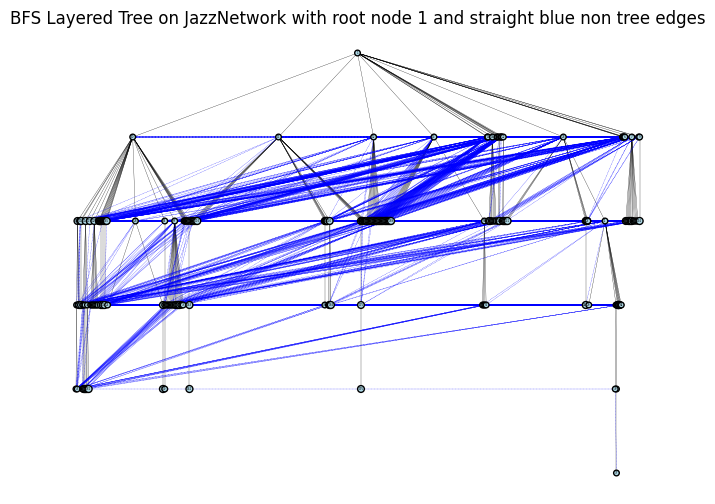

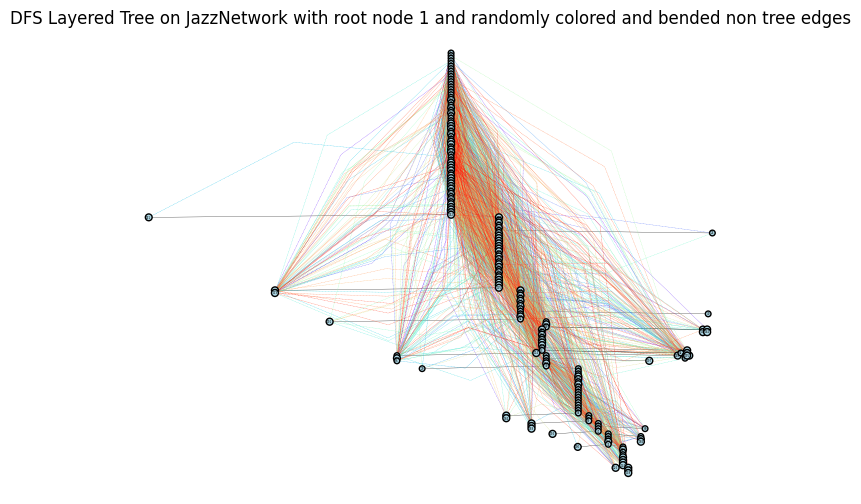

In [6]:
all_edges = extract_edges(graph)
non_tree_edges_bfs = missing_edges(bfs_result, all_edges)
non_tree_edges_dfs = missing_edges(dfs_result, all_edges)

draw_tree_with_all_edges(non_tree_edges_bfs, bfs_result, "BFS Layered Tree on JazzNetwork with root node 1 and straight blue non tree edges", random=False) #with straight blue lines
draw_tree_with_all_edges(non_tree_edges_dfs, dfs_result, "DFS Layered Tree on JazzNetwork with root node 1 and randomly colored and bended non tree edges") #with random curved lines

## changing root nodes to generate different spanning trees (with DFS)

We store all the photos of the trees in the corresponding folders. This way we can go through them and spot similarities and differences.

Folder to store the drawings:

In [ ]:
# if not already created by the user, create the output folder with subfolders for each file_name and their bfs and dfs subfolders

# list of file names
data_list = [data_name_1, data_name_2, data_name_3, data_name_4, data_name_5, data_name_6, data_name_7, data_name_8, data_name_9, data_name_10, data_name_11, data_name_12, data_name_13]



The folder already exists


Now, we can draw all the possible combinations of dfs trees: 

In [ ]:
# draw a dfs tree for each node of a graph and save images in a folder:


## Extra check about g.edges():

It looks like it's detecting edges both ways....

In [ ]:
import pydot

# Creazione di un grafo
graph = pydot.Dot(graph_type='digraph')

# Aggiunta di nodi
node_a = pydot.Node("A")
node_b = pydot.Node("B")
graph.add_node(node_a)
graph.add_node(node_b)

# Aggiunta di un bordo
edge_ab = pydot.Edge(node_a, node_b)
edge_ba = pydot.Edge(node_b, node_a)
graph.add_edge(edge_ab)
graph.add_edge(edge_ba)

# Ottenere i bordi del grafo
edges = graph.get_edges()

# Stampa dei bordi
for edge in edges:
    print(edge)